In [8]:
import numpy as np
import matplotlib.pyplot as plt
from plotsetup import *
import sympy as sp

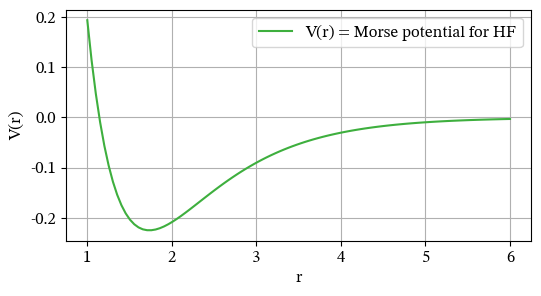

In [9]:
re = 1.733
a = 1.174
De = 0.225
def V(r, De=De, a=a, re=re):
    """Morse potential for HF in atomic units."""
    r = sp.Symbol('r')
    return De * (1 - sp.exp(-a * (r - re)))**2 - De

V_numeric = sp.lambdify('r', V('r'))


mu = 1741.1 # reduced mass of HF

n = 100
r = np.linspace(1, 6, 100)
fig, ax = plt.subplots(figsize=(6,3))
plt.plot(r, [V_numeric(ri) for ri in r], label='V(r) = Morse potential for HF')
plt.legend()
plt.xlabel('r')
plt.ylabel('V(r)')
plt.grid()
plt.show()

In [10]:
# compute analytic derivatives of Morse potential
max_order = 10
r_sym = sp.Symbol('r')

V_derivatives = [V(r_sym)]
for n in range(1, max_order + 1):
    derivative = V_derivatives[-1].diff(r_sym)
    V_derivatives.append(derivative)
    print(f"Derivative order {n}: {derivative}")


Derivative order 1: 30.9073192624065*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r)
Derivative order 2: -36.2851928140653*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) + 36.2851928140653*exp(-2.348*r)
Derivative order 3: 42.5988163637126*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) - 127.796449091138*exp(-2.348*r)
Derivative order 4: -50.0110104109986*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) + 350.07707287699*exp(-2.348*r)
Derivative order 5: 58.7129262225124*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) - 880.693893337686*exp(-2.348*r)
Derivative order 6: -68.9289753852295*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) + 2136.79823694212*exp(-2.348*r)
Derivative order 7: 80.9226171022595*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) - 5098.12487744235*exp(-2.348*r)
Derivative order 8: -95.0031524780526*(0.130740347873135 - exp(-1.174*r))*exp(-1.174*r) + 12065.4003647127*exp(-2.348*r)
Derivative order 9: 111.533701009234*(0.130740347873135 - exp(-1.174*r

In [11]:
from ipywidgets import IntSlider, VBox, HBox, Output, Layout
from IPython.display import display

# Taylor coefficients of the Morse potential about r = re
coeffs = [float(d.subs(r_sym, re)) / float(sp.factorial(k)) for k, d in enumerate(V_derivatives)]

def V_taylor(r, n):
    return sum(coeffs[k] * (r - re)**k for k in range(n + 1))

r_plot = np.linspace(1, 6, 200)
V_exact = np.array([V_numeric(ri) for ri in r_plot])

order_slider = IntSlider(description='order n', min=1, max=max_order, step=1, value=1,
                          continuous_update=True, layout=Layout(width='600px'))
plot_out = Output()

def update(*_):
    n_taylor = order_slider.value
    if n_taylor is None:  # guard against transient None during widget sync
        return
    with plot_out:
        plot_out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 2.5))
        ax.plot(r_plot, V_exact, label='V(r) = Morse potential')
        ax.plot(r_plot, V_taylor(r_plot, n_taylor), label=f'Taylor expansion, order {n_taylor}')
        ax.axvline(re, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel('r')
        ax.set_ylabel('V(r)')
        ax.set_ylim(-1.5 * De, 1.5 * De)
        ax.set_title('Morse potential and its Taylor expansion')
        ax.legend()
        ax.grid()
        plt.show()

order_slider.observe(update, names='value')

display(VBox([plot_out, order_slider]))
update()
